# Tutorial 08: Why RL? From Rejection Sampling to GRPO

You have a model and a reward function that can verify whether an answer is correct. How should you train?

The simplest approach is **Rejection Sampling Fine-Tuning (RFT)**: sample solutions, keep the correct ones, fine-tune with standard SFT loss. It's fast and stable.

But on harder tasks, RFT hits a ceiling. **GRPO** (Group Relative Policy Optimization) breaks through that ceiling by learning from *both* correct and incorrect solutions.

This tutorial runs both methods head-to-head on GSM8K math problems, compares their learning dynamics, and analyzes *why* they differ.

**What you'll learn:**
1. How RFT and GRPO work — with runnable code
2. A live head-to-head comparison on GSM8K
3. Why RFT plateaus and GRPO doesn't — with concrete model output examples
4. When to use which method

## The two approaches

Both RFT and GRPO start the same way: sample K solutions per problem, then grade them. The difference is in **what they train on**.

| | RFT | GRPO |
|---|---|---|
| **Correct solutions** | Train with SFT loss | Upweight (positive advantage) |
| **Wrong solutions** | Throw away | Downweight (negative advantage) |
| **Loss function** | Cross-entropy | Importance-weighted policy gradient |
| **Intuition** | "Do more of this" | "Do more of this, less of that" |

RFT is just SFT on the model's own correct outputs. GRPO is RL that learns from the full distribution of outputs — correct and incorrect.

## Setup

In [1]:
import asyncio
import re
import time
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import tinker
import torch
from tinker import TensorData

from tinker_cookbook.renderers import get_renderer, get_text_content
from tinker_cookbook.renderers.base import TrainOnWhat
from tinker_cookbook.supervised.data import conversation_to_datum

In [2]:
import datasets

_dataset = datasets.load_dataset("openai/gsm8k", "main")
train_data = _dataset["train"]
test_data = _dataset["test"]


def extract_gsm8k_answer(text: str) -> str:
    match = re.search(r"####\s*(.+)", text)
    if match:
        return match.group(1).replace(",", "").strip()
    raise ValueError("No #### answer found")


def extract_boxed(text: str) -> str | None:
    match = re.findall(r"\\boxed\{([^}]+)\}", text)
    return match[-1].strip() if match else None


def grade_answer(response: str, ground_truth: str) -> float:
    answer = extract_boxed(response)
    if answer is None:
        return 0.0
    return 1.0 if answer.replace(",", "").strip() == ground_truth.replace(",", "").strip() else 0.0


question_suffix = " Provide a step-by-step solution ending with \\boxed{answer}."

print(f"Loaded {len(train_data)} train / {len(test_data)} test GSM8K problems")

Loaded 7473 train / 1319 test GSM8K problems


In [3]:
# Training configuration — both methods use the same settings
N_STEPS = 30
BATCH_SIZE = 32       # problems per step
GROUP_SIZE = 16       # completions per problem
MAX_TOKENS = 1024
BASE_MODEL = "Qwen/Qwen3-8B"
EVAL_EVERY = 5
N_EVAL_PROBLEMS = 200

## Part 1: RFT (Rejection Sampling Fine-Tuning)

The RFT loop:
1. Sample K solutions per problem from the current model
2. Grade them — keep only correct ones
3. Run standard SFT (cross-entropy) on the correct solutions
4. Evaluate on the test set periodically

No advantages, no importance weights, no negative signal. Just **SFT on whatever the model gets right**.

In [4]:
# --- Setup RFT model ---
service_rft = tinker.ServiceClient()
tc_rft = await service_rft.create_lora_training_client_async(base_model=BASE_MODEL, rank=32)
tok_rft = tc_rft.get_tokenizer()
renderer_rft = get_renderer("qwen3", tok_rft)
adam_rft = tinker.AdamParams(learning_rate=1e-4, beta1=0.9, beta2=0.95)
samp_params_rft = tinker.SamplingParams(
    max_tokens=MAX_TOKENS, temperature=1.0, stop=renderer_rft.get_stop_sequences()
)


async def evaluate_rft():
    sc = await tc_rft.save_weights_and_get_sampling_client_async()
    ep = tinker.SamplingParams(max_tokens=MAX_TOKENS, temperature=0.0, stop=renderer_rft.get_stop_sequences())

    async def _one(row):
        convo = [{"role": "user", "content": row["question"] + question_suffix}]
        r = await sc.sample_async(prompt=renderer_rft.build_generation_prompt(convo), num_samples=1, sampling_params=ep)
        msg, _ = renderer_rft.parse_response(r.sequences[0].tokens)
        return grade_answer(get_text_content(msg), extract_gsm8k_answer(row["answer"]))

    problems = test_data.select(range(min(N_EVAL_PROBLEMS, len(test_data))))
    scores = await asyncio.gather(*[_one(row) for row in problems])
    return sum(scores) / len(scores)


# --- RFT Training Loop ---
rft_metrics = []
t0 = time.time()

for step in range(N_STEPS):
    t_step = time.time()
    batch_rows = train_data.select(range(step * BATCH_SIZE, step * BATCH_SIZE + BATCH_SIZE))

    # 1. Sample K solutions per problem
    sc_rft = await tc_rft.save_weights_and_get_sampling_client_async()

    async def _sample_rft(question):
        convo = [{"role": "user", "content": question + question_suffix}]
        prompt = renderer_rft.build_generation_prompt(convo)
        result = await sc_rft.sample_async(prompt=prompt, num_samples=GROUP_SIZE, sampling_params=samp_params_rft)
        return result, convo

    results = await asyncio.gather(*[_sample_rft(q) for q in batch_rows["question"]])

    # 2. Grade and keep only correct solutions
    correct_datums = []
    n_correct = 0
    n_total = 0
    n_solved = 0

    for (sample_result, convo), answer_text in zip(results, batch_rows["answer"]):
        gt = extract_gsm8k_answer(answer_text)
        problem_correct = 0
        for seq in sample_result.sequences:
            n_total += 1
            msg, _ = renderer_rft.parse_response(seq.tokens)
            content = get_text_content(msg)
            if grade_answer(content, gt) == 1.0:
                n_correct += 1
                problem_correct += 1
                full_convo = convo + [{"role": "assistant", "content": content}]
                correct_datums.append(conversation_to_datum(
                    full_convo, renderer_rft, max_length=2048,
                    train_on_what=TrainOnWhat.LAST_ASSISTANT_MESSAGE,
                ))
        if problem_correct > 0:
            n_solved += 1

    # 3. SFT step on correct solutions
    if correct_datums:
        fb = await tc_rft.forward_backward_async(correct_datums, loss_fn="cross_entropy")
        op = await tc_rft.optim_step_async(adam_rft)
        await fb.result_async()
        await op.result_async()

    sample_acc = n_correct / n_total if n_total else 0
    elapsed = time.time() - t0
    step_time = time.time() - t_step
    remaining = step_time * (N_STEPS - step - 1)

    entry = {"step": step, "sample_accuracy": sample_acc, "solve_rate": n_solved / BATCH_SIZE}

    if step % EVAL_EVERY == 0:
        test_acc = await evaluate_rft()
        entry["test_accuracy"] = test_acc
        print(f"RFT step {step:2d} | sample_acc: {sample_acc:.0%} | test: {test_acc:.1%} | {elapsed:.0f}s elapsed, ~{remaining/60:.0f}min remaining")
    else:
        print(f"RFT step {step:2d} | sample_acc: {sample_acc:.0%} | solved: {n_solved}/{BATCH_SIZE} | {elapsed:.0f}s elapsed, ~{remaining/60:.0f}min remaining")

    rft_metrics.append(entry)

# Final eval
rft_final = await evaluate_rft()
rft_metrics.append({"step": N_STEPS, "test_accuracy": rft_final})
print(f"\nRFT done! Final test accuracy: {rft_final:.1%} ({time.time()-t0:.0f}s total)")

RFT step  0 | sample_acc: 27% | test: 30.5% | 45s elapsed, ~22min remaining


RFT step  1 | sample_acc: 24% | solved: 22/32 | 128s elapsed, ~20min remaining


RFT step  2 | sample_acc: 35% | solved: 27/32 | 170s elapsed, ~19min remaining


RFT step  3 | sample_acc: 39% | solved: 27/32 | 218s elapsed, ~21min remaining


RFT step  4 | sample_acc: 50% | solved: 30/32 | 284s elapsed, ~27min remaining


...

RFT step 26 | sample_acc: 89% | solved: 31/32 | 1496s elapsed, ~2min remaining


RFT step 27 | sample_acc: 92% | solved: 30/32 | 1541s elapsed, ~1min remaining


RFT step 28 | sample_acc: 89% | solved: 32/32 | 1577s elapsed, ~1min remaining


RFT step 29 | sample_acc: 96% | solved: 32/32 | 1617s elapsed, ~0min remaining



RFT done! Final test accuracy: 93.5% (1645s total)


## Part 2: GRPO (Group Relative Policy Optimization)

GRPO uses **all** solutions — correct and incorrect — weighted by group-relative advantages:

```
advantage = reward - mean(rewards_in_group)
```

Correct solutions get positive advantage, wrong ones get negative advantage. The model learns to do more of the good **and less of the bad**.

The setup is identical to Part 1 — same model, same data, same grading, same prompts. The **only difference** is the training step: instead of SFT on correct solutions, we build importance-sampling datums with advantages for all solutions. (For a detailed walkthrough of GRPO datum construction, see [Tutorial 04](104_first_rl.py).)

In [5]:
# --- Setup GRPO model (fresh, same base) ---
service_grpo = tinker.ServiceClient()
tc_grpo = await service_grpo.create_lora_training_client_async(base_model=BASE_MODEL, rank=32)
tok_grpo = tc_grpo.get_tokenizer()
renderer_grpo = get_renderer("qwen3", tok_grpo)
adam_grpo = tinker.AdamParams(learning_rate=2e-5, beta1=0.9, beta2=0.95)
samp_params_grpo = tinker.SamplingParams(
    max_tokens=MAX_TOKENS, temperature=1.0, stop=renderer_grpo.get_stop_sequences()
)


async def evaluate_grpo():
    sc = await tc_grpo.save_weights_and_get_sampling_client_async()
    ep = tinker.SamplingParams(max_tokens=MAX_TOKENS, temperature=0.0, stop=renderer_grpo.get_stop_sequences())

    async def _one(row):
        convo = [{"role": "user", "content": row["question"] + question_suffix}]
        r = await sc.sample_async(prompt=renderer_grpo.build_generation_prompt(convo), num_samples=1, sampling_params=ep)
        msg, _ = renderer_grpo.parse_response(r.sequences[0].tokens)
        return grade_answer(get_text_content(msg), extract_gsm8k_answer(row["answer"]))

    problems = test_data.select(range(min(N_EVAL_PROBLEMS, len(test_data))))
    scores = await asyncio.gather(*[_one(row) for row in problems])
    return sum(scores) / len(scores)


# --- GRPO Training Loop ---
grpo_metrics = []
t0_grpo = time.time()

for step in range(N_STEPS):
    t_step = time.time()
    batch_rows = train_data.select(range(step * BATCH_SIZE, step * BATCH_SIZE + BATCH_SIZE))

    # 1. Sample K solutions per problem (identical to RFT)
    sc_grpo = await tc_grpo.save_weights_and_get_sampling_client_async()

    prompts_grpo = []
    coros_grpo = []
    for question in batch_rows["question"]:
        convo = [{"role": "user", "content": question + question_suffix}]
        prompt = renderer_grpo.build_generation_prompt(convo)
        coros_grpo.append(
            sc_grpo.sample_async(prompt=prompt, num_samples=GROUP_SIZE, sampling_params=samp_params_grpo)
        )
        prompts_grpo.append(prompt)

    sample_results_grpo = await asyncio.gather(*coros_grpo)

    # 2. Grade ALL solutions and compute group-relative advantages
    #    THIS IS THE KEY DIFFERENCE FROM RFT
    datums_grpo = []
    rewards_all = []
    n_correct_grpo = 0
    n_total_grpo = 0
    n_solved_grpo = 0
    n_degenerate = 0

    for sample_result, prompt, answer_text in zip(sample_results_grpo, prompts_grpo, batch_rows["answer"]):
        gt = extract_gsm8k_answer(answer_text)

        # Grade every solution (same grading as RFT)
        rewards_G = []
        tokens_G = []
        logprobs_G = []
        problem_correct = 0
        for seq in sample_result.sequences:
            tokens_G.append(seq.tokens)
            logprobs_G.append(seq.logprobs)
            msg, _ = renderer_grpo.parse_response(seq.tokens)
            content = get_text_content(msg)
            reward = grade_answer(content, gt)
            rewards_G.append(reward)
            n_total_grpo += 1
            if reward == 1.0:
                n_correct_grpo += 1
                problem_correct += 1

        if problem_correct > 0:
            n_solved_grpo += 1

        # Group-relative advantage: reward - mean(group)
        mean_reward = sum(rewards_G) / len(rewards_G)
        advantages_G = [r - mean_reward for r in rewards_G]
        rewards_all.append(mean_reward)

        # Skip degenerate groups (all same reward -> zero advantage -> no signal)
        if all(a == 0.0 for a in advantages_G):
            n_degenerate += 1
            continue

        # Build RL datums for ALL solutions (correct AND incorrect)
        ob_len = prompt.length - 1
        for tokens, logprobs, advantage in zip(tokens_G, logprobs_G, advantages_G):
            model_input = prompt.append(tinker.EncodedTextChunk(tokens=tokens[:-1]))
            target_tokens = [0] * ob_len + tokens
            padded_logprobs = [0.0] * ob_len + logprobs
            padded_advantages = [0.0] * ob_len + [advantage] * (model_input.length - ob_len)
            datums_grpo.append(tinker.Datum(
                model_input=model_input,
                loss_fn_inputs={
                    "target_tokens": TensorData.from_torch(torch.tensor(target_tokens)),
                    "logprobs": TensorData.from_torch(torch.tensor(padded_logprobs)),
                    "advantages": TensorData.from_torch(torch.tensor(padded_advantages)),
                },
            ))

    # 3. RL step with importance-weighted loss (instead of cross-entropy)
    if datums_grpo:
        fb = await tc_grpo.forward_backward_async(datums_grpo, loss_fn="importance_sampling")
        op = await tc_grpo.optim_step_async(adam_grpo)
        await fb.result_async()
        await op.result_async()

    sample_acc_grpo = n_correct_grpo / n_total_grpo if n_total_grpo else 0
    solve_rate_grpo = n_solved_grpo / BATCH_SIZE
    elapsed = time.time() - t0_grpo
    step_time = time.time() - t_step
    remaining = step_time * (N_STEPS - step - 1)

    entry = {
        "step": step,
        "sample_accuracy": sample_acc_grpo,
        "solve_rate": solve_rate_grpo,
        "reward": sum(rewards_all) / len(rewards_all) if rewards_all else 0,
        "n_degenerate": n_degenerate,
    }

    if step % EVAL_EVERY == 0:
        test_acc = await evaluate_grpo()
        entry["test_accuracy"] = test_acc
        print(f"GRPO step {step:2d} | sample_acc: {sample_acc_grpo:.0%} | test: {test_acc:.1%} | {elapsed:.0f}s elapsed, ~{remaining/60:.0f}min remaining")
    else:
        print(f"GRPO step {step:2d} | sample_acc: {sample_acc_grpo:.0%} | solved: {n_solved_grpo}/{BATCH_SIZE} | {elapsed:.0f}s elapsed, ~{remaining/60:.0f}min remaining")

    grpo_metrics.append(entry)

# Final eval
grpo_final = await evaluate_grpo()
grpo_metrics.append({"step": N_STEPS, "test_accuracy": grpo_final})
print(f"\nGRPO done! Final test accuracy: {grpo_final:.1%} ({time.time()-t0_grpo:.0f}s total)")

GRPO step  0 | sample_acc: 26% | test: 30.5% | 45s elapsed, ~22min remaining


GRPO step  1 | sample_acc: 22% | solved: 19/32 | 155s elapsed, ~30min remaining


GRPO step  2 | sample_acc: 30% | solved: 23/32 | 218s elapsed, ~29min remaining


GRPO step  3 | sample_acc: 24% | solved: 21/32 | 280s elapsed, ~27min remaining


GRPO step  4 | sample_acc: 30% | solved: 24/32 | 340s elapsed, ~25min remaining


...

GRPO step 26 | sample_acc: 82% | solved: 28/32 | 1763s elapsed, ~3min remaining


GRPO step 27 | sample_acc: 84% | solved: 30/32 | 1814s elapsed, ~2min remaining


GRPO step 28 | sample_acc: 87% | solved: 29/32 | 1875s elapsed, ~1min remaining


GRPO step 29 | sample_acc: 94% | solved: 32/32 | 1933s elapsed, ~0min remaining



GRPO done! Final test accuracy: 87.0% (1986s total)


## Results: Learning curves

Both models are evaluated with greedy decoding on 200 GSM8K test problems every 5 training steps.

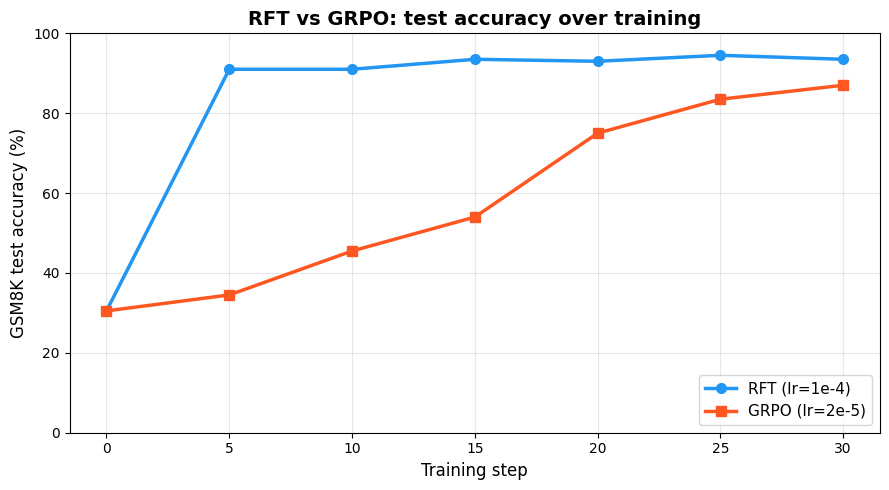

In [6]:
rft_eval = [(m["step"], m["test_accuracy"] * 100) for m in rft_metrics if "test_accuracy" in m]
grpo_eval = [(m["step"], m["test_accuracy"] * 100) for m in grpo_metrics if "test_accuracy" in m]

rft_x, rft_y = zip(*rft_eval) if rft_eval else ([], [])
grpo_x, grpo_y = zip(*grpo_eval) if grpo_eval else ([], [])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rft_x, rft_y, "o-", color="#2196F3", linewidth=2.5, markersize=7, label="RFT (lr=1e-4)")
ax.plot(grpo_x, grpo_y, "s-", color="#FF5722", linewidth=2.5, markersize=7, label="GRPO (lr=2e-5)")

ax.set_xlabel("Training step", fontsize=12)
ax.set_ylabel("GSM8K test accuracy (%)", fontsize=12)
ax.set_title("RFT vs GRPO: test accuracy over training", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## Results: Training signal

Compare how the training signal evolves:
- **RFT**: fraction of sampled solutions that are correct (sample accuracy) and solve rate (fraction of problems with at least 1 correct solution)
- **GRPO**: mean reward per batch

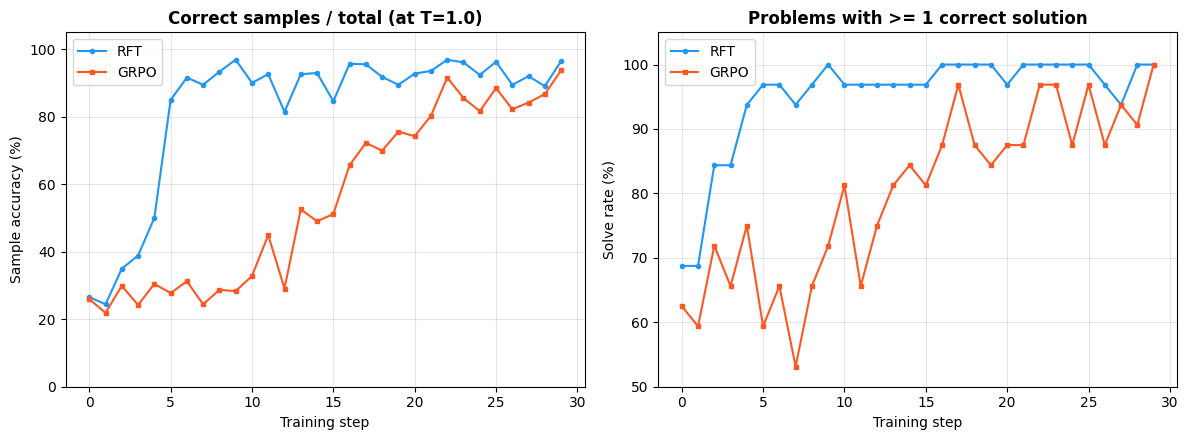

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Sample accuracy: both methods
rft_sa = [(m["step"], m["sample_accuracy"] * 100) for m in rft_metrics if "sample_accuracy" in m]
grpo_sa = [(m["step"], m["sample_accuracy"] * 100) for m in grpo_metrics if "sample_accuracy" in m]
if rft_sa:
    xs, ys = zip(*rft_sa)
    ax1.plot(xs, ys, "o-", color="#2196F3", linewidth=1.5, markersize=3, label="RFT")
if grpo_sa:
    xs2, ys2 = zip(*grpo_sa)
    ax1.plot(xs2, ys2, "s-", color="#FF5722", linewidth=1.5, markersize=3, label="GRPO")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Sample accuracy (%)")
ax1.set_title("Correct samples / total (at T=1.0)", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 105)

# Solve rate: both methods
rft_sr = [(m["step"], m["solve_rate"] * 100) for m in rft_metrics if "solve_rate" in m]
grpo_sr = [(m["step"], m["solve_rate"] * 100) for m in grpo_metrics if "solve_rate" in m]
if rft_sr:
    xs3, ys3 = zip(*rft_sr)
    ax2.plot(xs3, ys3, "o-", color="#2196F3", linewidth=1.5, markersize=3, label="RFT")
if grpo_sr:
    xs4, ys4 = zip(*grpo_sr)
    ax2.plot(xs4, ys4, "s-", color="#FF5722", linewidth=1.5, markersize=3, label="GRPO")
ax2.set_xlabel("Training step")
ax2.set_ylabel("Solve rate (%)")
ax2.set_title("Problems with >= 1 correct solution", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(50, 105)

plt.tight_layout()
plt.show()

## Analysis: Model output comparison

Let's sample from both trained models on the same test problems and compare their solutions side by side. This reveals *qualitative* differences that the aggregate metrics hide.

In [8]:
# Sample from both trained models + base on the same 5 test problems
eval_params = tinker.SamplingParams(
    max_tokens=MAX_TOKENS, temperature=0.0, stop=renderer_rft.get_stop_sequences()
)

# Get sampling clients — RFT and GRPO are already trained above
rft_sampler = await tc_rft.save_weights_and_get_sampling_client_async()
grpo_sampler = await tc_grpo.save_weights_and_get_sampling_client_async()

# Base model for 3-way comparison
service_base = tinker.ServiceClient()
tc_base = await service_base.create_lora_training_client_async(base_model=BASE_MODEL, rank=32)
base_sampler = await tc_base.save_weights_and_get_sampling_client_async()

# Pick 5 test problems
sample_problems = test_data.select(range(5))

for i, row in enumerate(sample_problems):
    question = row["question"]
    gt = extract_gsm8k_answer(row["answer"])
    print(f"\n{'='*80}")
    print(f"Problem {i+1}: {question[:120]}...")
    print(f"Ground truth: {gt}")
    print(f"{'='*80}")

    for name, sampler, rdr in [
        ("Base", base_sampler, renderer_rft),
        ("RFT", rft_sampler, renderer_rft),
        ("GRPO", grpo_sampler, renderer_grpo),
    ]:
        convo = [{"role": "user", "content": question + question_suffix}]
        prompt = rdr.build_generation_prompt(convo)
        result = await sampler.sample_async(prompt=prompt, num_samples=1, sampling_params=eval_params)
        msg, _ = rdr.parse_response(result.sequences[0].tokens)
        content = get_text_content(msg)

        boxed = extract_boxed(content)
        correct = grade_answer(content, gt) == 1.0

        print(f"\n--- {name} {'✓' if correct else '✗'} (answered: {boxed}) ---")
        print(content[:400])
        if len(content) > 400:
            print(f"... [{len(content)} chars total]")


Problem 1: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every da...
Ground truth: 18



--- Base ✓ (answered: 18) ---
<think>
Okay, let's see. Janet's ducks lay 16 eggs each day. So first, I need to figure out how many eggs she has to work with every day. Then, she uses some of them for her own breakfast and for baking muffins. After that, the remaining eggs are sold at the farmers' market. The question is asking how much money she makes each day from selling those eggs. Alright, let's break it down step by step.
... [3718 chars total]



--- RFT ✓ (answered: 18) ---


To determine how much Janet makes at the farmers' market, we need to calculate the number of eggs she sells and then multiply that by the price per egg.

1. **Total eggs laid per day**: 16
2. **Eggs eaten for breakfast**: 3
3. **Eggs used for muffins**: 4
4. **Eggs sold at the market**: $16 - 3 - 4 = 9$
5. **Price per egg**: $2
6. **Total earnings**: $9 \times 2 = 18$

Janet makes $\boxed{18}$ d
... [953 chars total]



--- GRPO ✓ (answered: 18) ---


Janet's ducks lay 16 eggs per day. She uses 3 eggs for breakfast and 4 eggs for baking muffins, totaling 7 eggs used each day. 

The number of eggs left to sell is calculated by subtracting the eggs used from the total eggs laid:
$$ 16 - 7 = 9 $$

Each egg is sold for $2, so the daily earnings from selling the eggs are:
$$ 9 \times 2 = 18 $$

Thus, Janet makes $\boxed{18}$ dollars every day at t
... [419 chars total]

Problem 2: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?...
Ground truth: 3



--- Base ✗ (answered: None) ---
<think>
Okay, let me try to figure out how many bolts of fiber are needed to make one robe. The problem says that a robe takes 2 bolts of blue fiber and half that much white fiber. Hmm, let me break this down step by step.

First, the blue fiber part is straightforward. It says 2 bolts. So, blue fiber required = 2 bolts. Got that part.

Now, the white fiber is half that much. Wait, half of what? T
... [3935 chars total]


...


--- RFT ✓ (answered: 540) ---


To find the total meters James runs in a week, we need to calculate the total distance for all his sprints. 

First, we know he runs 3 sprints each time and does this 3 times a week. So, the total number of sprints per week is:
$$ 3 \text{ sprints/time} \times 3 \text{ times/week} = 9 \text{ sprints/week} $$

Next, each sprint is 60 meters long. Therefore, the total distance he runs in a week is
... [1087 chars total]



--- GRPO ✓ (answered: 540) ---


To determine how many total meters James runs in a week, we can break the problem into two steps:

---

### **Step 1: Calculate the total number of sprints per week**

James runs **3 sprints** each time, and he does this **3 times a week**.  
So, the total number of sprints per week is:

$$
3 \text{ sprints/session} \times 3 \text{ sessions/week} = 9 \text{ sprints/week}
$$

---

### **Step 2: C
... [664 chars total]

Problem 5: Every day, Wendi feeds each of her chickens three cups of mixed chicken feed, containing seeds, mealworms and vegetables...
Ground truth: 20



--- Base ✗ (answered: None) ---
<think>
Okay, let's see. Wendi feeds her chickens every day, right? Each chicken gets three cups of mixed feed, and she splits it into three meals: morning, afternoon, and then the final one. The question is asking how many cups she needs to give in the final meal. 

First, let me make sure I understand the problem. She has 20 chickens. Each chicken gets 3 cups of feed per day. But she divides the
... [4101 chars total]



--- RFT ✓ (answered: 20) ---


To determine how many cups of feed Wendi needs to give her chickens in the final meal of the day, we can follow these steps:

1. **Calculate the total feed given in the morning and afternoon:**
   - Morning feed: 15 cups
   - Afternoon feed: 25 cups
   - Total feed given so far: $15 + 25 = 40$ cups

2. **Determine the total feed required for the day:**
   - Each chicken is fed 3 cups of feed per
... [1511 chars total]



--- GRPO ✓ (answered: 20) ---


To determine how many cups of feed Wendi needs to give her chickens in the final meal of the day, we can follow these steps:

---

### **Step 1: Calculate the total daily feed required**

Wendi has **20 chickens**, and each chicken receives **3 cups of feed per day**.  
So, the total daily feed required is:

$$
20 \text{ chickens} \times 3 \text{ cups/chicken} = 60 \text{ cups}
$$

---

### **St
... [909 chars total]


## Analysis: Solution diversity

A key difference between RFT and GRPO is how they affect the model's output **diversity**. Let's sample K=16 solutions from each model on the same problem and compare:
- How many unique answers does each model produce?
- What fraction are correct?

This directly tests the "entropy collapse" hypothesis — that RFT makes the model overconfident.

In [9]:
# Sample K=16 solutions from each model on 20 test problems
diversity_params = tinker.SamplingParams(
    max_tokens=MAX_TOKENS, temperature=1.0, stop=renderer_rft.get_stop_sequences()
)
K = 16
N_DIVERSITY_PROBLEMS = 20
diversity_problems = test_data.select(range(N_DIVERSITY_PROBLEMS))

diversity_results = {"Base": [], "RFT": [], "GRPO": []}

for name, sampler, rdr in [
    ("Base", base_sampler, renderer_rft),
    ("RFT", rft_sampler, renderer_rft),
    ("GRPO", grpo_sampler, renderer_grpo),
]:
    async def _sample_k(row, _sampler=sampler, _rdr=rdr):
        convo = [{"role": "user", "content": row["question"] + question_suffix}]
        prompt = _rdr.build_generation_prompt(convo)
        result = await _sampler.sample_async(prompt=prompt, num_samples=K, sampling_params=diversity_params)
        gt = extract_gsm8k_answer(row["answer"])
        answers = []
        n_correct = 0
        for seq in result.sequences:
            msg, _ = _rdr.parse_response(seq.tokens)
            content = get_text_content(msg)
            boxed = extract_boxed(content)
            answers.append(boxed)
            if grade_answer(content, gt) == 1.0:
                n_correct += 1
        unique_answers = len(set(a for a in answers if a is not None))
        return {"n_correct": n_correct, "n_unique": unique_answers, "n_total": K}

    results = await asyncio.gather(*[_sample_k(row) for row in diversity_problems])
    diversity_results[name] = results
    avg_correct = sum(r["n_correct"] for r in results) / len(results)
    avg_unique = sum(r["n_unique"] for r in results) / len(results)
    print(f"{name:5s}: avg correct={avg_correct:.1f}/{K}, avg unique answers={avg_unique:.1f}")

Base : avg correct=2.9/16, avg unique answers=0.5


RFT  : avg correct=14.7/16, avg unique answers=1.6


GRPO : avg correct=13.9/16, avg unique answers=0.9


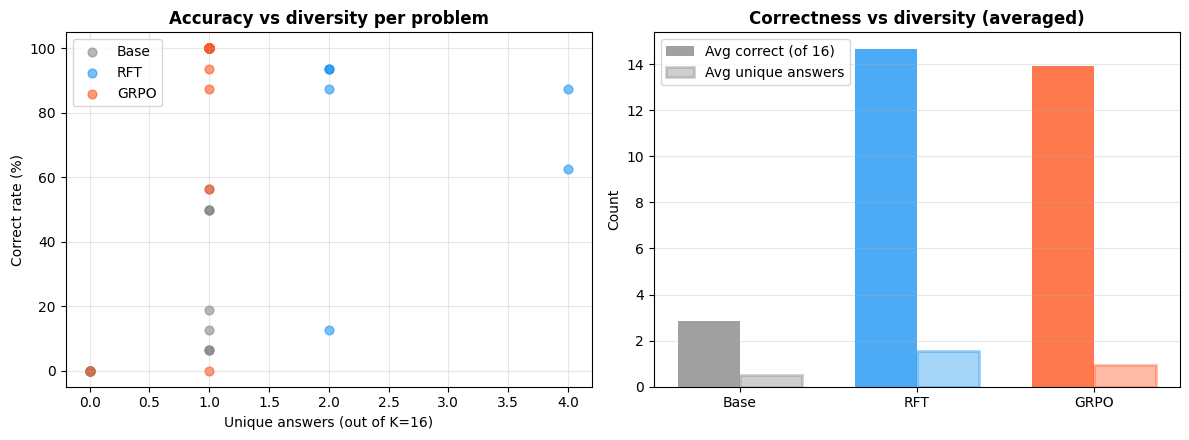

In [10]:
# Visualize diversity vs correctness
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"Base": "#888888", "RFT": "#2196F3", "GRPO": "#FF5722"}

for name in ["Base", "RFT", "GRPO"]:
    results = diversity_results[name]
    correct_rates = [r["n_correct"] / r["n_total"] * 100 for r in results]
    unique_counts = [r["n_unique"] for r in results]
    ax1.scatter(unique_counts, correct_rates, color=colors[name], alpha=0.6, s=40, label=name)

ax1.set_xlabel("Unique answers (out of K=16)")
ax1.set_ylabel("Correct rate (%)")
ax1.set_title("Accuracy vs diversity per problem", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bar chart of averages
names = ["Base", "RFT", "GRPO"]
avg_correct = [sum(r["n_correct"] for r in diversity_results[n]) / len(diversity_results[n]) for n in names]
avg_unique = [sum(r["n_unique"] for r in diversity_results[n]) / len(diversity_results[n]) for n in names]

x = range(len(names))
width = 0.35
bars1 = ax2.bar([i - width/2 for i in x], avg_correct, width, label="Avg correct (of 16)", color=[colors[n] for n in names], alpha=0.8)
bars2 = ax2.bar([i + width/2 for i in x], avg_unique, width, label="Avg unique answers", color=[colors[n] for n in names], alpha=0.4, edgecolor=[colors[n] for n in names], linewidth=2)
ax2.set_xticks(list(x))
ax2.set_xticklabels(names)
ax2.set_ylabel("Count")
ax2.set_title("Correctness vs diversity (averaged)", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Why RFT plateaus

RFT's training signal degrades in three ways:

### 1. Redundant gradients
As the model improves, its correct solutions become increasingly *similar*. Training on near-identical outputs produces diminishing gradient updates — the model is just reinforcing what it already knows.

### 2. No negative signal
RFT throws away wrong solutions. It can never say "stop doing this." If the model makes a systematic error on certain problem types, RFT has no mechanism to correct it — it can only wait for a lucky correct sample, and reinforce that.

### 3. Easy problem bias
Easy problems generate many more correct solutions than hard problems. The gradient is dominated by easy-problem signal, even though the model already masters them.

> **Think of it this way:** RFT is like a student who only reviews problems they already solved. They get very fast at those problems, but never learn from their mistakes on harder ones.

## How GRPO breaks through

| RFT limitation | How GRPO fixes it |
|---|---|
| Redundant gradients on easy problems | **Advantage weighting**: rare correct solutions on hard problems get higher advantage |
| No negative signal | **Negative advantages**: wrong solutions are actively penalized, pushing the model away from failure modes |
| Easy problem bias | **Group-relative centering**: advantages are computed *within* each problem, so hard and easy problems contribute equally |

For a problem where the model gets 3/16 solutions right:
- **RFT:** trains on 3 correct solutions with uniform weight
- **GRPO:** trains on all 16 solutions. The 3 correct ones get advantage **+0.81**, the 13 wrong ones get advantage **-0.19**. The model learns what worked AND what didn't.

## Summary

| | RFT | GRPO |
|---|---|---|
| **Speed** | Fast (5 steps to plateau) | Slower (15+ steps) |
| **Ceiling** | Limited by task difficulty | Keeps improving |
| **Signal** | Correct solutions only | Correct + incorrect |
| **Stability** | Very stable (pure SFT) | Needs LR tuning |
| **Best for** | Easy tasks, quick wins | Hard tasks, pushing limits |

**The key insight:** RL isn't just "fancier SFT." It provides a qualitatively different training signal. When correct solutions become redundant and mistakes go uncorrected, RL's ability to learn from the full distribution of outputs — both good and bad — is what enables continued improvement.

## Next steps

- **Harder tasks:** Run on Hendrycks MATH with `python -m tinker_cookbook.recipes.math_rft.train env=math` to see the RFT plateau more dramatically (L5 stuck at 60%)
- **GRPO recipe:** `python -m tinker_cookbook.recipes.math_rl.train env=math`
- **RL hyperparameters:** `tutorials/402_rl_hyperparams.py`
- **Research notes:** `tinker_cookbook/recipes/math_rft/NOTES.md` for the full MATH comparison and warm-start experiment